## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté capitulo nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [7]:
# Importamos las librerías necesarias
import pandas as pd      # Para manejar y analizar datos en tablas
import numpy as np       # Para cálculos numéricos y operaciones matemáticas
import seaborn as sns    # Para gráficos estadísticos y visualización
import matplotlib.pyplot as plt  # Para gráficos básicos y personalizados

# Cargamos el archivo CSV
df = pd.read_csv("M30 Online Retail.csv", encoding="latin1")

# Mostramos las primeras filas para revisar que se cargó correctamente
df.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom


In [8]:
# Análisis Exploratorio
# Revisamos la estructura del dataset, valores nulos y duplicados
df.info()       # Información general de columnas y tipos de datos
df.describe()   # Estadísticas básicas de las variables numéricas
df.isnull().sum()  # Conteo de valores nulos por columna

# Eliminamos las filas con valores nulos en CUSTOMER_ID y DESCRIPTION
df_clean = df.dropna(subset=["CUSTOMER_ID", "DESCRIPTION"])

# Eliminamos posibles duplicados
df_clean = df_clean.drop_duplicates()

# Convertimos la columna INVOICE_DATE a formato de fecha
df_clean["INVOICE_DATE"] = pd.to_datetime(df_clean["INVOICE_DATE"], format="%d/%m/%Y %H:%M")

# Revisamos nuevamente para confirmar que se transformó correctamente
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   INVOICE_NO    541909 non-null  str    
 1   STOCK_CODE    541909 non-null  str    
 2   DESCRIPTION   540455 non-null  str    
 3   QUANTITY      541909 non-null  int64  
 4   INVOICE_DATE  541909 non-null  str    
 5   UNIT_PRICE    541909 non-null  float64
 6   CUSTOMER_ID   406829 non-null  float64
 7   REGION        541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   INVOICE_NO    401604 non-null  str           
 1   STOCK_CODE    401604 non-null  str           
 2   DESCRIPTION   401604 non-null  str           
 3   QUANTITY      401604 non-null  int64         
 4

## Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [9]:
# 1: Obtener los clientes únicos
customer = df_clean[["CUSTOMER_ID"]].drop_duplicates()

In [10]:
# 2: Obtener la última fecha de compra por cliente
max_purchase = df_clean.groupby("CUSTOMER_ID")["INVOICE_DATE"].max().reset_index()

In [11]:
# 3: Calcular la métrica de Recency (días desde la última compra)
fecha_referencia = df_clean["INVOICE_DATE"].max()
max_purchase["RECENCY"] = (fecha_referencia - max_purchase["INVOICE_DATE"]).dt.days

In [12]:
# 4: Unir el DataFrame de clientes únicos con el de última fecha de compra
customer = pd.merge(customer, max_purchase, on="CUSTOMER_ID")

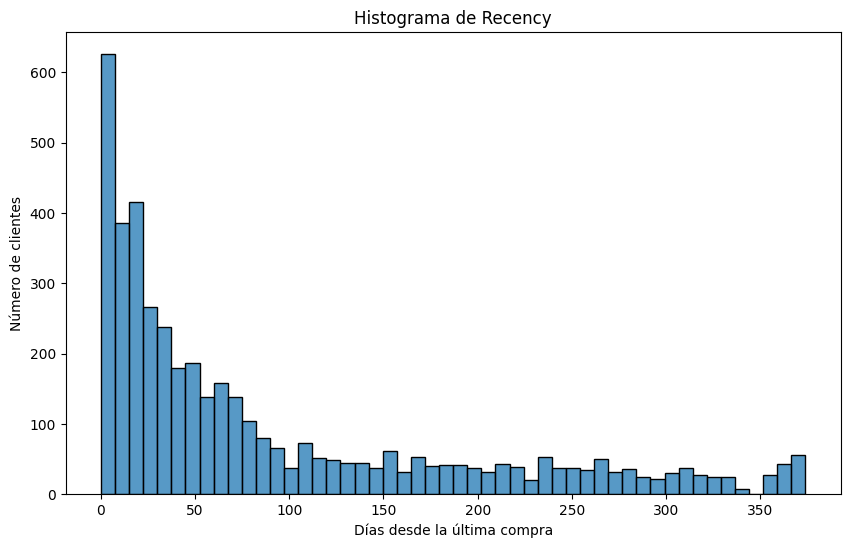

In [13]:
# 5: Graficar un histograma de Recency
plt.figure(figsize=(10,6))
sns.histplot(customer["RECENCY"], bins=50, kde=False)
plt.title("Histograma de Recency")
plt.xlabel("Días desde la última compra")
plt.ylabel("Número de clientes")
plt.show()

In [14]:
# 6: Imprimir la estadística de resumen para Recency
customer["RECENCY"].describe()

count    4372.000000
mean       91.123056
std       100.946554
min         0.000000
25%        16.000000
50%        49.000000
75%       142.000000
max       374.000000
Name: RECENCY, dtype: float64

## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [15]:
# 1: Obtener el número de compras por cliente
frequency = df_clean.groupby("CUSTOMER_ID")["INVOICE_NO"].nunique().reset_index()

In [16]:
# 2: Unir el DataFrame que acabamos de crear con el de los clientes únicos
customer = pd.merge(customer, frequency, on="CUSTOMER_ID")

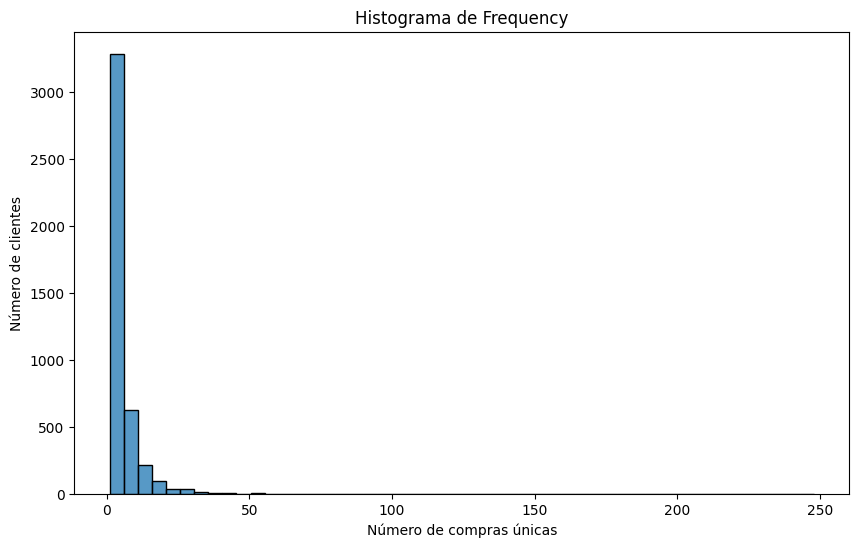

In [17]:
# 3: Graficar un histograma de Frequency
plt.figure(figsize=(10,6))
sns.histplot(customer["INVOICE_NO"], bins=50, kde=False)
plt.title("Histograma de Frequency")
plt.xlabel("Número de compras únicas")
plt.ylabel("Número de clientes")
plt.show()

In [18]:
# 4: Imprimir la Estadística de Resumen para Frequency
customer["INVOICE_NO"].describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: INVOICE_NO, dtype: float64

## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [19]:
# 1: Calcular el monto total por cada compra
df_clean["MONETARY"] = df_clean["QUANTITY"] * df_clean["UNIT_PRICE"]

# Obtener el valor monetario de compra por cliente
monetary = df_clean.groupby("CUSTOMER_ID")["MONETARY"].sum().reset_index()

In [20]:
# 2: Unir el DataFrame que acabamos de crear con el de los clientes únicos
customer = pd.merge(customer, monetary, on="CUSTOMER_ID")

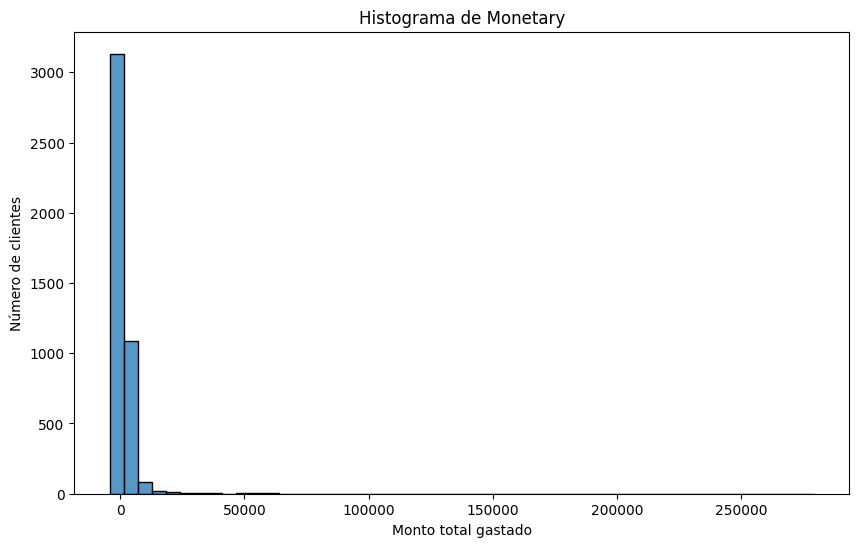

In [21]:
# 3: Graficar un histograma de Monetary
plt.figure(figsize=(10,6))
sns.histplot(customer["MONETARY"], bins=50, kde=False)
plt.title("Histograma de Monetary")
plt.xlabel("Monto total gastado")
plt.ylabel("Número de clientes")
plt.show()

In [22]:
# 4: Imprimir la Estadística de Resumen para Monetary
customer["MONETARY"].describe()

count      4372.000000
mean       1893.531433
std        8218.696204
min       -4287.630000
25%         291.795000
50%         644.070000
75%        1608.335000
max      279489.020000
Name: MONETARY, dtype: float64

## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [23]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [24]:
# 1: Importa la librería de kMeans
from sklearn.cluster import KMeans

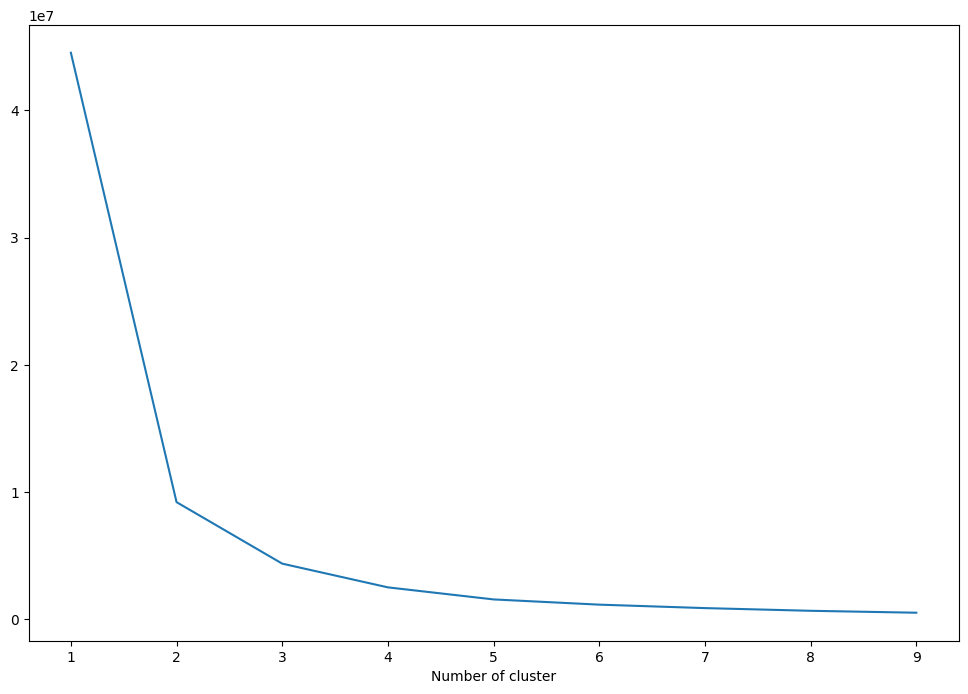

In [26]:
# 2: Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse = {}
recency = customer[["RECENCY"]]

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adjunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Gráfico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [27]:
# 3: Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[["RECENCY"]])

# Obtener las predicciones
customer["RECENCY_CLUSTER"] = kmeans.predict(customer[["RECENCY"]])

# Ordenar los clusters
customer = order_cluster("RECENCY_CLUSTER", "RECENCY", customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby("RECENCY_CLUSTER")["RECENCY"].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,528.0,306.907197,40.650555,246.0,269.0,303.0,338.0,374.0
1,628.0,185.367834,32.666602,132.0,156.0,184.0,213.0,245.0
2,1059.0,77.814920,22.830097,48.0,59.0,73.0,93.5,131.0
3,2157.0,17.397311,13.188805,0.0,6.0,16.0,28.0,47.0


In [29]:
# 4: Instanciar el algoritmo con 4 clusters para Frequency 

# Renombramos la columna INVOICE_NO a FREQUENCY si aún no lo está
customer.rename(columns={"INVOICE_NO": "FREQUENCY"}, inplace=True)

# Instanciamos el algoritmo con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenamos el algoritmo con la métrica Frequency
kmeans.fit(customer[["FREQUENCY"]])

# Obtenemos las predicciones
customer["FREQUENCY_CLUSTER"] = kmeans.predict(customer[["FREQUENCY"]])

# Ordenamos los clusters (en este caso ascendente, porque más frecuencia = mejor cliente)
customer = order_cluster("FREQUENCY_CLUSTER", "FREQUENCY", customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("FREQUENCY_CLUSTER")["FREQUENCY"].describe()

,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,3835.0,2.945502,2.146658,1.0,1.0,2.0,4.00,9.0
1,494.0,16.032389,6.247349,10.0,11.0,14.0,19.00,36.0
2,40.0,58.325000,22.847754,38.0,43.0,51.5,63.75,128.0
3,3.0,213.666667,40.501029,169.0,196.5,224.0,236.00,248.0


In [ ]:
# 5: Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[["MONETARY"]])

# Obtener las predicciones
customer["MONETARY_CLUSTER"] = kmeans.predict(customer[["MONETARY"]])

# Ordenar los clusters
customer = order_cluster("MONETARY_CLUSTER", "MONETARY", customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("MONETARY_CLUSTER")["MONETARY"].describe()

,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,4329.0,1342.587756,1990.244947,-4287.63,289.9600,636.14,1545.410,17588.26
1,36.0,35713.422222,14793.060840,18573.68,24695.2375,30800.45,51102.760,65892.08
2,4.0,114381.037500,19190.632799,88125.38,106942.2875,118470.02,125908.770,132458.73
3,3.0,241083.226667,47963.737800,187322.17,221880.3300,256438.49,267963.755,279489.02


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [31]:
# 1: Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer["SCORE"] = customer["RECENCY_CLUSTER"] + customer["FREQUENCY_CLUSTER"] + customer["MONETARY_CLUSTER"]

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer[["RECENCY_CLUSTER", "FREQUENCY_CLUSTER", "MONETARY_CLUSTER", "SCORE"]].mean()

RECENCY_CLUSTER      2.108188
FREQUENCY_CLUSTER    0.133349
MONETARY_CLUSTER     0.012123
SCORE                2.253660
dtype: float64

In [32]:
# 2: Crea una función que asigne lo siguiente:
# Si score <= 1 entonces 'Low-Value'
# Si score >1 y <=4 entonces 'Average'
# Si score >4 y <=6 entonces 'Potential'
# Si score >6 entonces 'High-Value'

def segment(score):
    if score <= 1:
        return "Low-Value"
    elif score > 1 and score <= 4:
        return "Average"
    elif score > 4 and score <= 6:
        return "Potential"
    else:
        return "High-Value"

# Crear una columna aplicando esta función al campo 'SCORE'
customer["SEGMENT"] = customer["SCORE"].apply(segment)

In [33]:
# 3: Vamos a dar un vistazo a la tabla final
customer.head()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,17850.0,2020-02-10 14:38:00,302,35,5303.48,0,1,0,1,Low-Value
1,13047.0,2020-11-08 12:10:00,31,18,3079.10,3,1,0,4,Average
2,12583.0,2020-12-07 08:07:00,2,18,7187.34,3,1,0,4,Average
3,13748.0,2020-09-05 09:45:00,95,5,948.25,2,0,0,2,Average
4,15100.0,2020-01-13 17:09:00,330,6,635.10,0,0,0,0,Low-Value


In [34]:
# 4: Imprime la proporción o el total de clientes por segmento
customer["SEGMENT"].value_counts()

SEGMENT
Average       3164
Low-Value     1148
Potential       52
High-Value       8
Name: count, dtype: int64

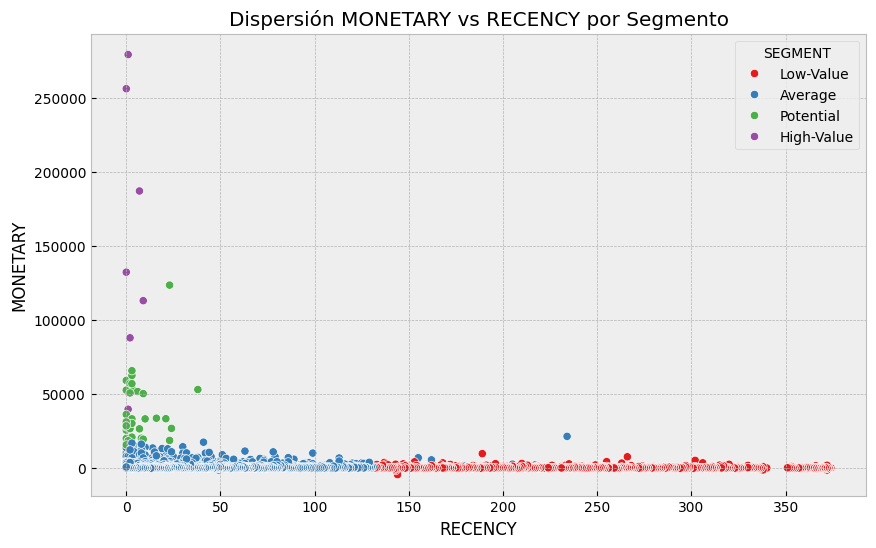

In [35]:
# 5: Define un estilo 'bmh'
plt.style.use("bmh")

# Filtra los valores para RECENCY < 4000
df_plot = customer[customer["RECENCY"] < 4000]

# Crea un gráfico de dispersión de 'MONETARY' VS 'RECENCY' por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_plot, x="RECENCY", y="MONETARY", hue="SEGMENT", palette="Set1")
plt.title("Dispersión MONETARY vs RECENCY por Segmento")
plt.show()

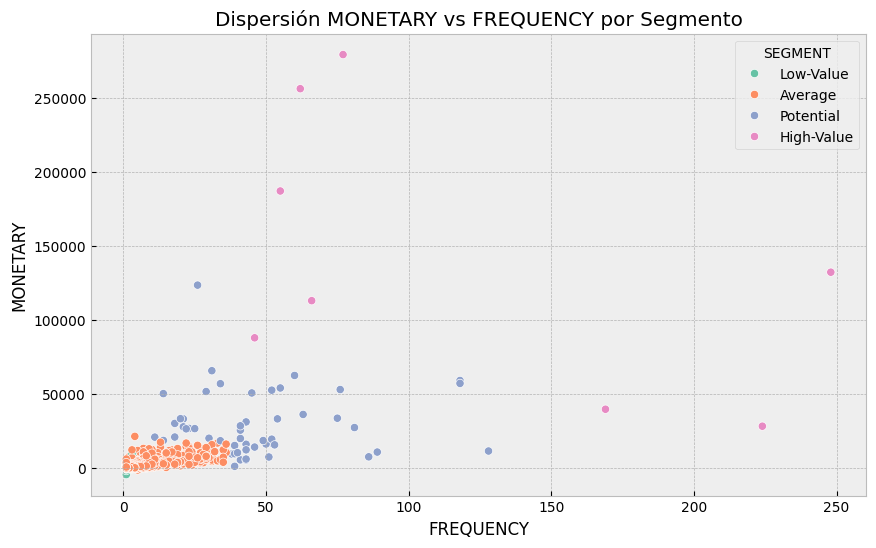

In [36]:
# 6: Crea un gráfico de dispersión de 'MONETARY' vs 'FREQUENCY' por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(data=customer, x="FREQUENCY", y="MONETARY", hue="SEGMENT", palette="Set2")
plt.title("Dispersión MONETARY vs FREQUENCY por Segmento")
plt.show()